In [2]:
import pandas as pd
import glob
import os

# Path to all CSV files in the datasets folder
data_path = r"C:\Users\natet\EnbridgeProject\data\Wind Farm A\datasets\*.csv"
all_files = glob.glob(data_path)

print(f"Found {len(all_files)} CSV files")

# Load and combine all files
dfs = []
for f in all_files:
    df_temp = pd.read_csv(f, sep=';')
    dfs.append(df_temp)

df_all = pd.concat(dfs, ignore_index=True)
print(f"Total rows loaded: {len(df_all)}")
print(f"\nstatus_type_id distribution across all files:")
print(df_all['status_type_id'].value_counts())
print(f"\nAsset IDs present: {sorted(df_all['asset_id'].unique())}")

Found 22 CSV files
Total rows loaded: 1196747

status_type_id distribution across all files:
status_type_id
0    1053736
4     119322
3      23689
Name: count, dtype: int64

Asset IDs present: [np.int64(0), np.int64(10), np.int64(11), np.int64(13), np.int64(21)]


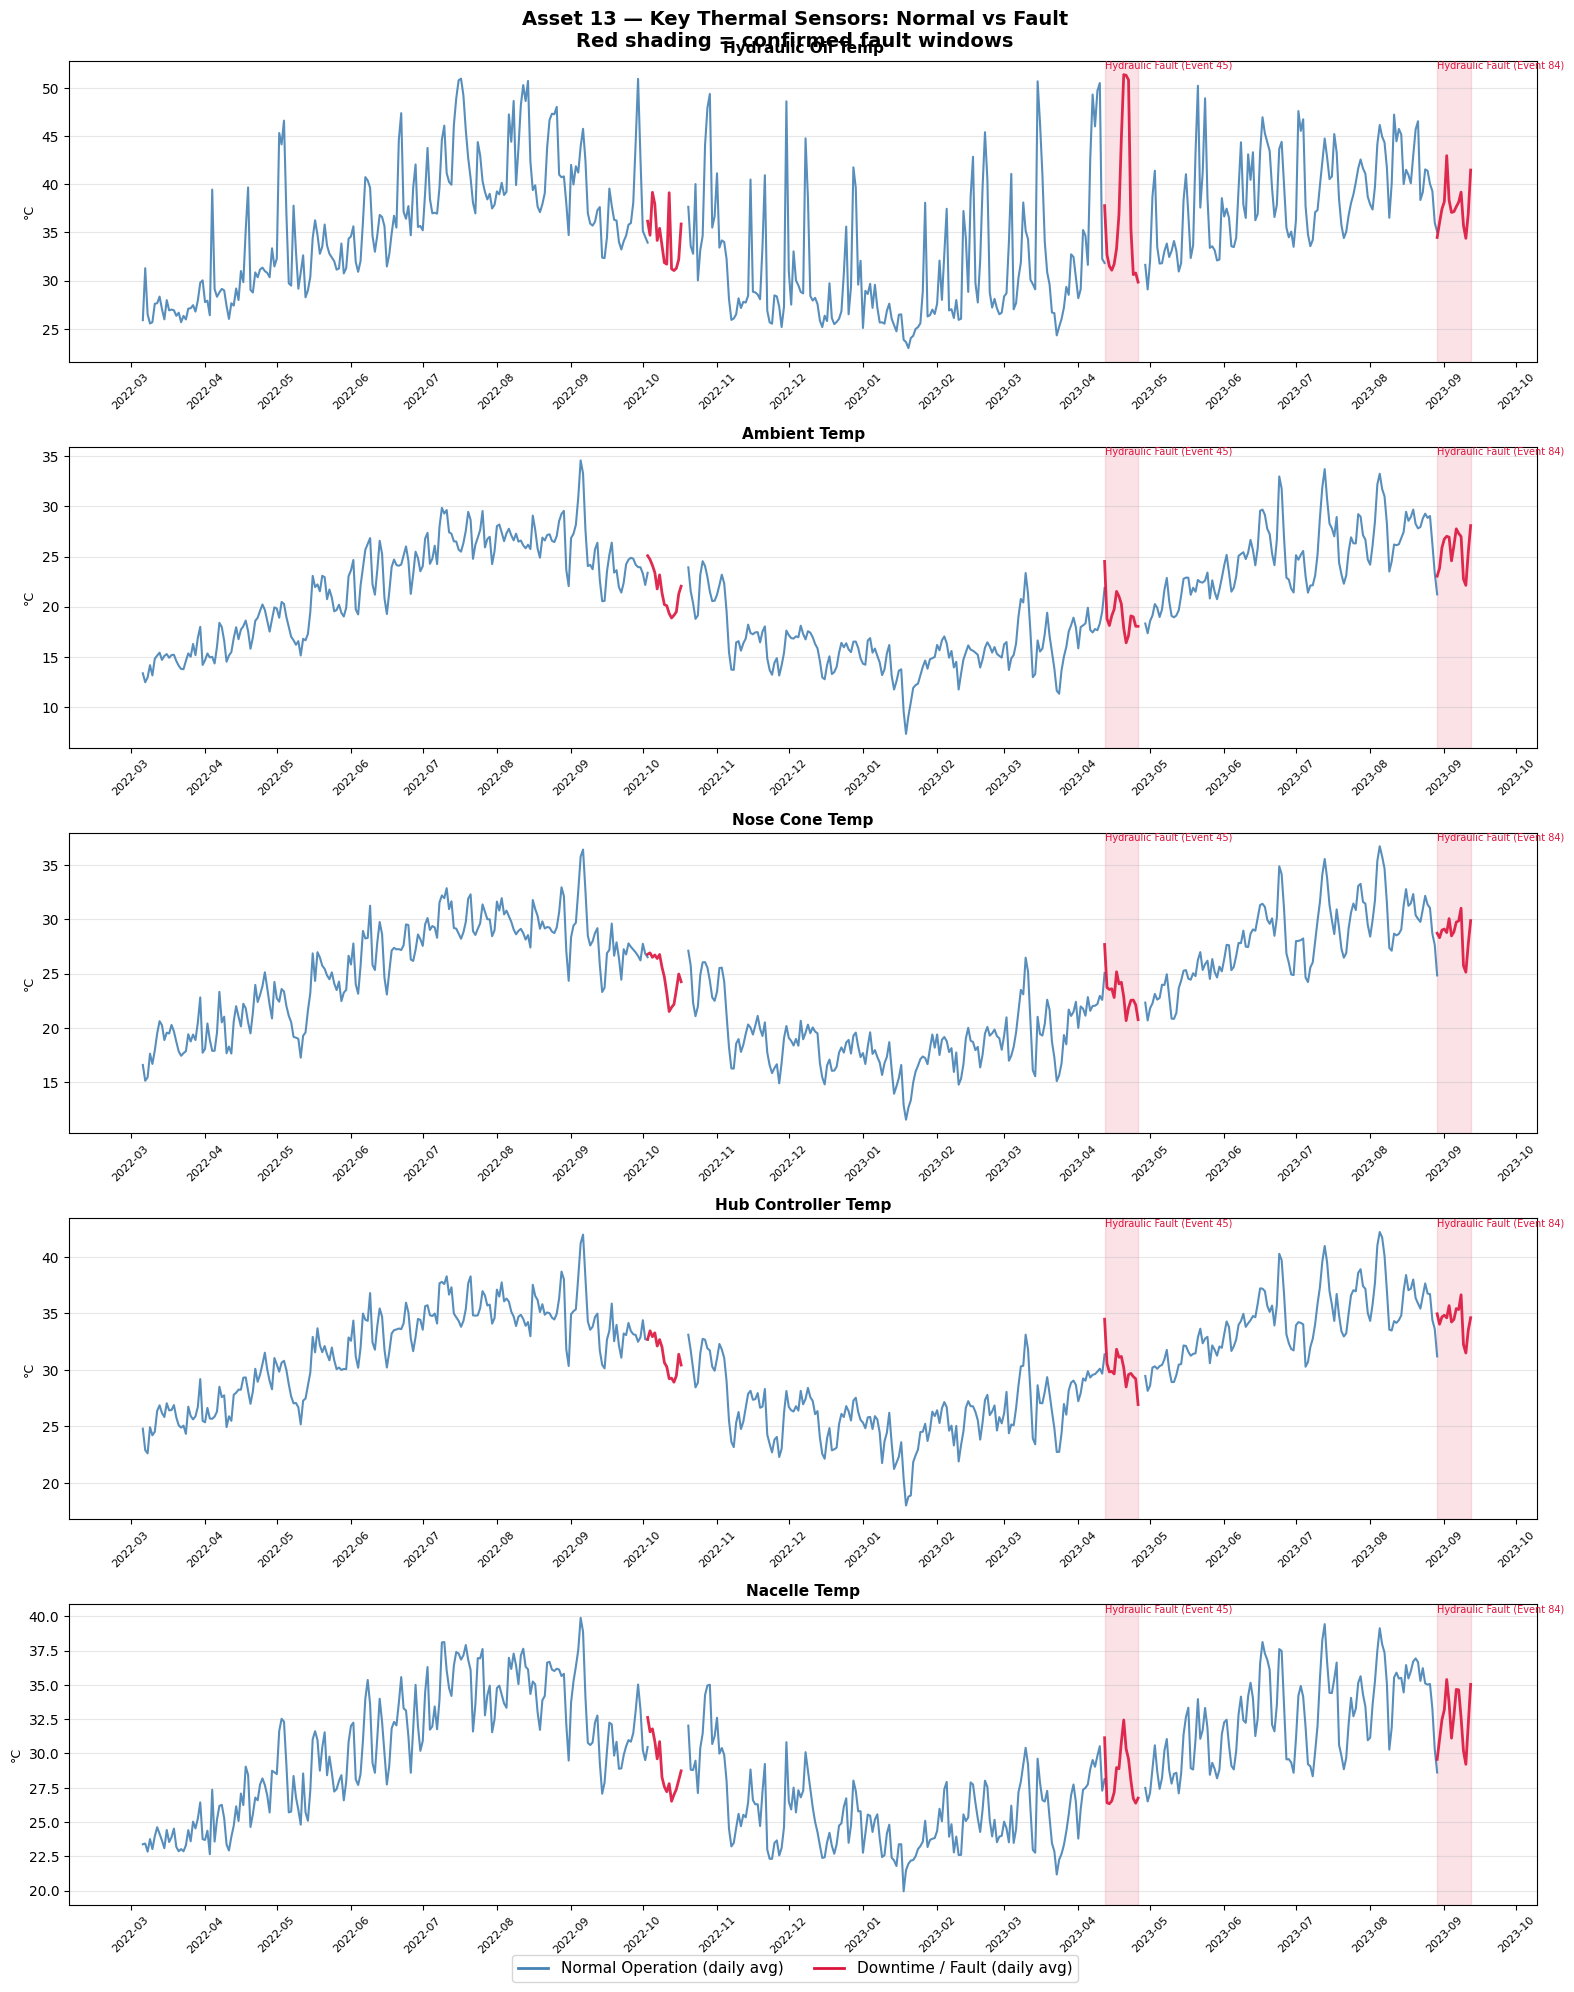

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from matplotlib.lines import Line2D

# Filtered to 5 key sensors
top5 = {
    'sensor_41_avg': 'Hydraulic Oil Temp',
    'sensor_0_avg':  'Ambient Temp',
    'sensor_53_avg': 'Nose Cone Temp',
    'sensor_6_avg':  'Hub Controller Temp',
    'sensor_43_avg': 'Nacelle Temp',
}

# Asset 13, all statuses
df_a13 = df_all[df_all['asset_id'] == 13].copy()
df_a13['time_stamp'] = pd.to_datetime(df_a13['time_stamp'])
df_a13 = df_a13.sort_values('time_stamp').set_index('time_stamp')

# Separate normal and fault, resample to daily mean
normal_daily = df_a13[df_a13['status_type_id'].isin([0, 2])][list(top5.keys())].resample('D').mean()
fault_daily  = df_a13[df_a13['status_type_id'] == 4][list(top5.keys())].resample('D').mean()

# Confirmed fault windows
fault_windows = [
    ('2023-04-12', '2023-04-26', 'Hydraulic Fault (Event 45)'),
    ('2023-08-29', '2023-09-12', 'Hydraulic Fault (Event 84)'),
]

fig, axes = plt.subplots(5, 1, figsize=(16, 20))

for i, (col, label) in enumerate(top5.items()):
    ax = axes[i]

    ax.plot(normal_daily.index, normal_daily[col],
            color='steelblue', linewidth=1.5, alpha=0.9)
    ax.plot(fault_daily.index, fault_daily[col],
            color='crimson', linewidth=2, alpha=0.9)

    for start, end, name in fault_windows:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   color='crimson', alpha=0.12, label=name)
        ax.text(pd.Timestamp(start), ax.get_ylim()[1], name,
                fontsize=7, color='crimson', va='top')

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('°C', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(axis='y', alpha=0.3)

legend_elements = [
    Line2D([0], [0], color='steelblue', linewidth=2, label='Normal Operation (daily avg)'),
    Line2D([0], [0], color='crimson', linewidth=2, label='Downtime / Fault (daily avg)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, -0.01))

fig.suptitle('Asset 13 — Key Thermal Sensors: Normal vs Fault\nRed shading = confirmed fault windows',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

top5 = {
    'sensor_41_avg': 'Hydraulic Oil Temp',
    'sensor_0_avg':  'Ambient Temp',
    'sensor_53_avg': 'Nose Cone Temp',
    'sensor_6_avg':  'Hub Controller Temp',
    'sensor_43_avg': 'Nacelle Temp',
}

# Confirmed fault START dates for asset 13
faults = {
    'Hydraulic Fault (Event 45)': '2023-04-19',
    'Hydraulic Fault (Event 84)': '2023-09-05',
}

df_a13 = df_all[df_all['asset_id'] == 13].copy()
df_a13['time_stamp'] = pd.to_datetime(df_a13['time_stamp'])
df_a13 = df_a13.sort_values('time_stamp').set_index('time_stamp')
daily = df_a13[list(top5.keys())].resample('D').mean()

output_path = r"C:\Users\natet\EnbridgeProject\Asset13_PreFault_Analysis.pdf"

with PdfPages(output_path) as pdf:

    for fault_name, fault_date in faults.items():
        fault_dt = pd.Timestamp(fault_date)

        # 30 days before fault
        pre_fault = daily[fault_dt - pd.Timedelta(days=30): fault_dt].copy()

        # Baseline: 90 days of normal operation well before the fault window
        baseline_end   = fault_dt - pd.Timedelta(days=60)
        baseline_start = fault_dt - pd.Timedelta(days=150)
        baseline = daily[baseline_start:baseline_end].copy()

        fig, axes = plt.subplots(5, 1, figsize=(14, 20))
        fig.suptitle(f'Asset 13 — Pre-Fault Sensor Analysis\n{fault_name} | 30 Days Before Fault vs Baseline',
                     fontsize=13, fontweight='bold')

        for i, (col, label) in enumerate(top5.items()):
            ax = axes[i]

            # Baseline stats
            b_mean = baseline[col].mean()
            b_std  = baseline[col].std()

            # Normalize pre-fault to days-before-fault (x axis: -30 to 0)
            pre_fault_vals = pre_fault[col].values
            days_before = np.arange(-len(pre_fault_vals) + 1, 1)

            # Colour by deviation from baseline
            colors = []
            for v in pre_fault_vals:
                z = (v - b_mean) / b_std if b_std > 0 else 0
                if z > 2:   colors.append('crimson')
                elif z > 1: colors.append('orange')
                else:       colors.append('steelblue')

            # Baseline band
            ax.axhspan(b_mean - b_std, b_mean + b_std,
                       color='steelblue', alpha=0.1, label='Normal baseline ±1σ')
            ax.axhspan(b_mean - 2*b_std, b_mean + 2*b_std,
                       color='steelblue', alpha=0.05, label='Normal baseline ±2σ')
            ax.axhline(b_mean, color='steelblue', linewidth=1.5,
                       linestyle='--', alpha=0.7, label=f'Baseline mean ({b_mean:.1f}°C)')

            # Pre-fault values as bar chart coloured by severity
            ax.bar(days_before, pre_fault_vals, color=colors, alpha=0.8, width=0.8)

            # Fault marker
            ax.axvline(x=0, color='crimson', linewidth=2.5,
                       linestyle='-', label='Fault occurs →')

            # Annotate peak deviation
            peak_idx = np.argmax(np.abs(pre_fault_vals - b_mean))
            peak_day = days_before[peak_idx]
            peak_val = pre_fault_vals[peak_idx]
            peak_z   = (peak_val - b_mean) / b_std if b_std > 0 else 0
            ax.annotate(f'Peak: {peak_val:.1f}°C\n({peak_z:+.1f}σ)',
                        xy=(peak_day, peak_val),
                        xytext=(peak_day - 5, peak_val + b_std),
                        fontsize=8, color='crimson',
                        arrowprops=dict(arrowstyle='->', color='crimson'))

            ax.set_title(label, fontsize=10, fontweight='bold')
            ax.set_ylabel('°C', fontsize=8)
            ax.set_xlabel('Days Before Fault', fontsize=8)
            ax.set_xlim(-31, 2)
            ax.legend(fontsize=7, loc='upper left')
            ax.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close()

    # ── Summary page: which sensor deviated earliest? ──
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('Asset 13 — Early Warning Summary\nDays Before Fault Each Sensor First Exceeded 1σ Above Baseline',
                 fontsize=13, fontweight='bold')

    for ax, (fault_name, fault_date) in zip(axes, faults.items()):
        fault_dt = pd.Timestamp(fault_date)
        pre_fault = daily[fault_dt - pd.Timedelta(days=30): fault_dt].copy()
        baseline  = daily[fault_dt - pd.Timedelta(days=150): fault_dt - pd.Timedelta(days=60)].copy()

        first_warning = {}
        for col, label in top5.items():
            b_mean = baseline[col].mean()
            b_std  = baseline[col].std()
            z = (pre_fault[col] - b_mean) / b_std
            exceeded = z[z > 1]
            if not exceeded.empty:
                days_before = (fault_dt - exceeded.index[0]).days
                first_warning[label] = days_before
            else:
                first_warning[label] = 0

        sensors = list(first_warning.keys())
        days    = list(first_warning.values())
        bar_colors = ['crimson' if d >= 14 else 'orange' if d >= 7 else 'steelblue' for d in days]

        bars = ax.barh(sensors, days, color=bar_colors, alpha=0.85)
        ax.axvline(x=7,  color='orange', linewidth=1.5, linestyle='--', alpha=0.7, label='7-day warning')
        ax.axvline(x=14, color='green',  linewidth=1.5, linestyle='--', alpha=0.7, label='14-day warning')

        for bar, d in zip(bars, days):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{d} days', va='center', fontsize=9, fontweight='bold')

        ax.set_xlabel('Days Before Fault First Exceeded 1σ', fontsize=10)
        ax.set_title(fault_name, fontsize=10, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(axis='x', alpha=0.3)
        ax.set_xlim(0, 35)

    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

print(f"PDF saved to: {output_path}")

PDF saved to: C:\Users\natet\EnbridgeProject\Asset13_PreFault_Analysis.pdf


In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

top5 = {
    'sensor_41_avg': 'Hydraulic Oil Temp',
    'sensor_0_avg':  'Ambient Temp',
    'sensor_53_avg': 'Nose Cone Temp',
    'sensor_6_avg':  'Hub Controller Temp',
    'sensor_43_avg': 'Nacelle Temp',
}

# All confirmed anomaly events from the event log
all_faults = [
    (0,  'Hydraulic group',          '2023-06-10'),
    (0,  'Generator bearing failure','2023-08-06'),
    (0,  'Hydraulic group',          '2023-10-12'),
    (10, 'Generator bearing failure','2022-12-26'),
    (10, 'Hydraulic group',          '2023-09-09'),
    (10, 'Gearbox failure',          '2023-10-11'),
    (11, 'Transformer failure',      '2023-07-28'),
    (13, 'Hydraulic group',          '2023-04-19'),
    (13, 'Hydraulic group',          '2023-09-05'),
    (21, 'Hydraulic group',          '2023-08-12'),
    (21, 'Gearbox failure',          '2023-10-10'),
    (21, 'Gearbox bearings damaged', '2023-10-06'),
]

# Precompute daily averages per asset
daily_per_asset = {}
for asset_id in [0, 10, 11, 13, 21]:
    df_a = df_all[df_all['asset_id'] == asset_id].copy()
    df_a['time_stamp'] = pd.to_datetime(df_a['time_stamp'])
    df_a = df_a.sort_values('time_stamp').set_index('time_stamp')
    daily_per_asset[asset_id] = df_a[list(top5.keys())].resample('D').mean()

output_path = r"C:\Users\natet\EnbridgeProject\WindFarmA_AllFaults_PreFault_Analysis.pdf"

# Store early warning days for summary
summary_records = []

with PdfPages(output_path) as pdf:

    # ── Title page ──
    fig = plt.figure(figsize=(16, 9))
    fig.patch.set_facecolor('#1F4E79')
    fig.text(0.5, 0.65, 'Enbridge Wind Farm A',          ha='center', fontsize=32, color='white', fontweight='bold')
    fig.text(0.5, 0.55, 'Pre-Fault Sensor Analysis',     ha='center', fontsize=24, color='#ADD8E6')
    fig.text(0.5, 0.45, 'All Assets — All 12 Fault Events', ha='center', fontsize=16, color='white')
    fig.text(0.5, 0.35, '30 Days Before Fault vs Baseline', ha='center', fontsize=14, color='#ADD8E6')
    fig.text(0.5, 0.25, 'March 2026  |  Confidential',   ha='center', fontsize=12, color='#ADD8E6')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── One page per fault event ──
    for asset_id, fault_type, fault_date in all_faults:
        fault_dt = pd.Timestamp(fault_date)
        daily    = daily_per_asset[asset_id]

        # Pre-fault window: 30 days before
        pre_fault = daily[fault_dt - pd.Timedelta(days=30): fault_dt].copy()

        # Baseline: 60-150 days before fault (normal operation window)
        baseline = daily[fault_dt - pd.Timedelta(days=150): fault_dt - pd.Timedelta(days=60)].copy()

        if len(pre_fault) < 5 or len(baseline) < 10:
            continue  # skip if not enough data

        fig, axes = plt.subplots(5, 1, figsize=(14, 20))
        fig.suptitle(f'Asset {asset_id} — Pre-Fault Analysis\n{fault_type} | {fault_date} | 30 Days Before Fault vs Baseline',
                     fontsize=13, fontweight='bold')

        for i, (col, label) in enumerate(top5.items()):
            ax = axes[i]

            b_mean = baseline[col].mean()
            b_std  = baseline[col].std()

            pre_vals   = pre_fault[col].values
            days_before = np.arange(-len(pre_vals) + 1, 1)

            colors = []
            for v in pre_vals:
                z = (v - b_mean) / b_std if b_std > 0 else 0
                colors.append('crimson' if z > 2 else 'orange' if z > 1 else 'steelblue')

            ax.axhspan(b_mean - b_std,   b_mean + b_std,   color='steelblue', alpha=0.1, label='Baseline ±1σ')
            ax.axhspan(b_mean - 2*b_std, b_mean + 2*b_std, color='steelblue', alpha=0.05, label='Baseline ±2σ')
            ax.axhline(b_mean, color='steelblue', linewidth=1.5, linestyle='--',
                       alpha=0.7, label=f'Baseline mean ({b_mean:.1f}°C)')

            ax.bar(days_before, pre_vals, color=colors, alpha=0.8, width=0.8)
            ax.axvline(x=0, color='crimson', linewidth=2.5, label='Fault occurs →')

            # Annotate peak
            if len(pre_vals) > 0 and b_std > 0:
                peak_idx = np.argmax(np.abs(pre_vals - b_mean))
                peak_val = pre_vals[peak_idx]
                peak_z   = (peak_val - b_mean) / b_std
                peak_day = days_before[peak_idx]
                ax.annotate(f'Peak: {peak_val:.1f}°C\n({peak_z:+.1f}σ)',
                            xy=(peak_day, peak_val),
                            xytext=(peak_day - 5, peak_val + b_std),
                            fontsize=8, color='crimson',
                            arrowprops=dict(arrowstyle='->', color='crimson'))

            ax.set_title(label, fontsize=10, fontweight='bold')
            ax.set_ylabel('°C', fontsize=8)
            ax.set_xlabel('Days Before Fault', fontsize=8)
            ax.set_xlim(-31, 2)
            ax.legend(fontsize=7, loc='upper left')
            ax.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close()

        # Record early warning days for summary
        for col, label in top5.items():
            b_mean = baseline[col].mean()
            b_std  = baseline[col].std()
            if b_std > 0:
                z = (pre_fault[col] - b_mean) / b_std
                exceeded = z[z > 1]
                days_warning = (fault_dt - exceeded.index[0]).days if not exceeded.empty else 0
            else:
                days_warning = 0
            summary_records.append({
                'Asset': f'Asset {asset_id}',
                'Fault Type': fault_type,
                'Fault Date': fault_date,
                'Sensor': label,
                'Days Warning': days_warning
            })

    # ── Summary page 1: heatmap of warning days ──
    summary_df = pd.DataFrame(summary_records)
    pivot = summary_df.pivot_table(
        index=['Asset', 'Fault Type', 'Fault Date'],
        columns='Sensor',
        values='Days Warning'
    ).reset_index()

    fig, ax = plt.subplots(figsize=(18, 10))
    ax.axis('off')

    col_labels = ['Asset', 'Fault Type', 'Fault Date'] + list(top5.values())
    cell_data  = pivot.values.tolist()

    table = ax.table(
        cellText=[[str(c) for c in row] for row in cell_data],
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 2.2)

    # Header styling
    for j in range(len(col_labels)):
        table[0, j].set_facecolor('#1F4E79')
        table[0, j].set_text_props(color='white', fontweight='bold')

    # Cell colour by days warning
    for i, row in enumerate(cell_data):
        for j, val in enumerate(row):
            if j >= 3:  # sensor columns only
                try:
                    days = float(val)
                    if days >= 14:   color = '#c8f7c5'   # green
                    elif days >= 7:  color = '#ffeaa7'   # yellow
                    elif days > 0:   color = '#fab1a0'   # orange
                    else:            color = '#ffffff'
                except:
                    color = '#f2f7fc'
                table[i+1, j].set_facecolor(color)
            else:
                table[i+1, j].set_facecolor('#f2f7fc' if i % 2 == 0 else 'white')

    ax.set_title('Wind Farm A — Early Warning Days by Fault & Sensor\n'
                 'Green = 14+ days warning | Yellow = 7-14 days | Orange = <7 days | White = no warning detected',
                 fontsize=12, fontweight='bold', pad=20)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── Summary page 2: average warning days per sensor across all faults ──
    fig, ax = plt.subplots(figsize=(12, 6))

    avg_warning = summary_df.groupby('Sensor')['Days Warning'].mean().sort_values(ascending=True)
    bar_colors  = ['#c8f7c5' if d >= 14 else '#ffeaa7' if d >= 7 else '#fab1a0' for d in avg_warning.values]

    bars = ax.barh(avg_warning.index, avg_warning.values, color=bar_colors, alpha=0.9, edgecolor='grey')
    ax.axvline(x=7,  color='orange', linewidth=2, linestyle='--', label='7-day warning threshold')
    ax.axvline(x=14, color='green',  linewidth=2, linestyle='--', label='14-day warning threshold')

    for bar, val in zip(bars, avg_warning.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.0f} days avg', va='center', fontsize=10, fontweight='bold')

    ax.set_xlabel('Average Days Before Fault First Exceeded 1σ', fontsize=11)
    ax.set_title('Wind Farm A — Average Early Warning Days per Sensor\nAcross All 12 Confirmed Fault Events',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, 38)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── Summary page 3: breakdown by fault type ──
    fig, ax = plt.subplots(figsize=(12, 7))

    fault_avg = summary_df[summary_df['Sensor'] == 'Hydraulic Oil Temp'].groupby('Fault Type')['Days Warning'].mean().sort_values()
    colors    = ['#c8f7c5' if d >= 14 else '#ffeaa7' if d >= 7 else '#fab1a0' for d in fault_avg.values]

    bars = ax.barh(fault_avg.index, fault_avg.values, color=colors, alpha=0.9, edgecolor='grey')
    ax.axvline(x=7,  color='orange', linewidth=2, linestyle='--', label='7-day warning')
    ax.axvline(x=14, color='green',  linewidth=2, linestyle='--', label='14-day warning')

    for bar, val in zip(bars, fault_avg.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.0f} days avg', va='center', fontsize=10, fontweight='bold')

    ax.set_xlabel('Avg Days Warning from Hydraulic Oil Temp', fontsize=11)
    ax.set_title('Wind Farm A — Hydraulic Oil Temp Early Warning by Fault Type\nAverage days before fault crossed 1σ above baseline',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, 38)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

print(f"PDF saved to: {output_path}")
print(f"\nAverage warning days per sensor across all 12 faults:")
print(summary_df.groupby('Sensor')['Days Warning'].mean().sort_values(ascending=False).round(1).to_string())

PDF saved to: C:\Users\natet\EnbridgeProject\WindFarmA_AllFaults_PreFault_Analysis.pdf

Average warning days per sensor across all 12 faults:
Sensor
Ambient Temp           26.7
Nose Cone Temp         26.7
Hub Controller Temp    23.9
Hydraulic Oil Temp     22.0
Nacelle Temp           16.5


In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

# ── Derived feature engineering ──────────────────────────────────────────────
def build_daily(asset_id):
    df = df_all[df_all['asset_id'] == asset_id].copy()
    df['time_stamp'] = pd.to_datetime(df['time_stamp'])
    df = df.sort_values('time_stamp').set_index('time_stamp')

    # Raw columns we need
    cols_needed = [
        'sensor_0_avg',   # ambient temp
        'sensor_11_avg',  # gearbox bearing temp
        'sensor_12_avg',  # gearbox oil temp
        'sensor_13_avg',  # generator bearing DE
        'sensor_14_avg',  # generator bearing NDE
        'sensor_41_avg',  # hydraulic oil temp
        'sensor_38_avg', 'sensor_39_avg', 'sensor_40_avg',  # HV transformer
        'sensor_8_avg',   # choke coil
        'sensor_36_avg',  # IGBT rotor
        'sensor_6_avg',   # hub controller
        'sensor_43_avg',  # nacelle temp
        'sensor_53_avg',  # nose cone
        'sensor_15_avg', 'sensor_17_avg', 'sensor_19_avg',  # stator / split ring
        'sensor_9_avg',   # VCP board
        'wind_speed_3_avg',
        'power_30_avg',
        'sensor_18_avg', 'sensor_18_std',   # generator RPM
        'sensor_52_avg', 'sensor_52_std',   # rotor RPM
        'sensor_5_avg',                      # pitch angle
    ]
    available = [c for c in cols_needed if c in df.columns]
    daily = df[available].resample('D').mean()

    # ── Derived features ─────────────────────────────────────────────────────

    # 1. Temp above ambient (removes seasonal bias entirely)
    for col, label in [('sensor_11_avg','gearbox_bearing'),
                       ('sensor_12_avg','gearbox_oil'),
                       ('sensor_13_avg','gen_bearing_de'),
                       ('sensor_14_avg','gen_bearing_nde'),
                       ('sensor_41_avg','hydraulic_oil')]:
        if col in daily.columns and 'sensor_0_avg' in daily.columns:
            daily[f'{label}_above_ambient'] = daily[col] - daily['sensor_0_avg']

    # 2. Power efficiency ratio — actual power vs expected from wind³
    #    Filter low-wind days to avoid noise (wind < 3 m/s unreliable)
    if 'power_30_avg' in daily.columns and 'wind_speed_3_avg' in daily.columns:
        wind3 = daily['wind_speed_3_avg'] ** 3
        wind3[wind3 < 27] = np.nan  # mask wind < 3 m/s
        daily['power_efficiency'] = daily['power_30_avg'] / wind3

    # 3. Generator RPM instability (std/mean coefficient of variation)
    if 'sensor_18_std' in daily.columns and 'sensor_18_avg' in daily.columns:
        daily['gen_rpm_instability'] = daily['sensor_18_std'] / daily['sensor_18_avg'].replace(0, np.nan)

    # 4. Rotor RPM instability
    if 'sensor_52_std' in daily.columns and 'sensor_52_avg' in daily.columns:
        daily['rotor_rpm_instability'] = daily['sensor_52_std'] / daily['sensor_52_avg'].replace(0, np.nan)

    return daily

print("Building daily features for all assets...")
daily_per_asset = {aid: build_daily(aid) for aid in [0, 10, 11, 13, 21]}
print("Done.")
for aid, d in daily_per_asset.items():
    print(f"  Asset {aid}: {len(d.columns)} features, {len(d)} days")

Building daily features for all assets...
Done.
  Asset 0: 33 features, 660 days
  Asset 10: 33 features, 689 days
  Asset 11: 33 features, 536 days
  Asset 13: 33 features, 560 days
  Asset 21: 33 features, 540 days


In [18]:
# ── Fault-specific sensor groups including derived features ──────────────────
fault_sensors = {
    'Hydraulic group': {
        'sensor_41_avg':          'Hydraulic Oil Temp (°C)',
        'hydraulic_oil_above_ambient': 'Hydraulic Oil Above Ambient (°C)',
        'sensor_6_avg':           'Hub Controller Temp (°C)',
        'sensor_43_avg':          'Nacelle Temp (°C)',
        'power_efficiency':       'Power Efficiency (kW/m³s⁻³)',
    },
    'Generator bearing failure': {
        'sensor_13_avg':          'Generator Bearing DE (°C)',
        'sensor_14_avg':          'Generator Bearing NDE (°C)',
        'gen_bearing_de_above_ambient':  'Gen Bearing DE Above Ambient (°C)',
        'gen_bearing_nde_above_ambient': 'Gen Bearing NDE Above Ambient (°C)',
        'sensor_15_avg':          'Stator Winding Ph1 (°C)',
        'sensor_19_avg':          'Split Ring Temp (°C)',
        'gen_rpm_instability':    'Generator RPM Instability (CV)',
        'power_efficiency':       'Power Efficiency (kW/m³s⁻³)',
    },
    'Gearbox failure': {
        'sensor_11_avg':          'Gearbox Bearing Temp (°C)',
        'sensor_12_avg':          'Gearbox Oil Temp (°C)',
        'gearbox_bearing_above_ambient': 'Gearbox Bearing Above Ambient (°C)',
        'gearbox_oil_above_ambient':     'Gearbox Oil Above Ambient (°C)',
        'gen_rpm_instability':    'Generator RPM Instability (CV)',
        'rotor_rpm_instability':  'Rotor RPM Instability (CV)',
        'power_efficiency':       'Power Efficiency (kW/m³s⁻³)',
    },
    'Gearbox bearings damaged': {
        'sensor_11_avg':          'Gearbox Bearing Temp (°C)',
        'sensor_12_avg':          'Gearbox Oil Temp (°C)',
        'gearbox_bearing_above_ambient': 'Gearbox Bearing Above Ambient (°C)',
        'gearbox_oil_above_ambient':     'Gearbox Oil Above Ambient (°C)',
        'gen_rpm_instability':    'Generator RPM Instability (CV)',
        'rotor_rpm_instability':  'Rotor RPM Instability (CV)',
        'power_efficiency':       'Power Efficiency (kW/m³s⁻³)',
    },
    'Transformer failure': {
        'sensor_38_avg':          'HV Transformer Phase L1 (°C)',
        'sensor_39_avg':          'HV Transformer Phase L2 (°C)',
        'sensor_40_avg':          'HV Transformer Phase L3 (°C)',
        'sensor_8_avg':           'Choke Coil Temp (°C)',
        'sensor_36_avg':          'IGBT Rotor Temp (°C)',
        'power_efficiency':       'Power Efficiency (kW/m³s⁻³)',
    },
}

all_faults = [
    (0,  'Hydraulic group',          '2023-06-10'),
    (0,  'Generator bearing failure','2023-08-06'),
    (0,  'Hydraulic group',          '2023-10-12'),
    (10, 'Generator bearing failure','2022-12-26'),
    (10, 'Hydraulic group',          '2023-09-09'),
    (10, 'Gearbox failure',          '2023-10-11'),
    (11, 'Transformer failure',      '2023-07-28'),
    (13, 'Hydraulic group',          '2023-04-19'),
    (13, 'Hydraulic group',          '2023-09-05'),
    (21, 'Hydraulic group',          '2023-08-12'),
    (21, 'Gearbox failure',          '2023-10-10'),
    (21, 'Gearbox bearings damaged', '2023-10-06'),
]

output_path = r"C:\Users\natet\EnbridgeProject\WindFarmA_DerivedFeatures_PreFault_Analysis.pdf"
summary_records = []

with PdfPages(output_path) as pdf:

    # ── Title page ────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 9))
    fig.patch.set_facecolor('#1F4E79')
    fig.text(0.5, 0.65, 'Enbridge Wind Farm A',
             ha='center', fontsize=32, color='white', fontweight='bold')
    fig.text(0.5, 0.55, 'Pre-Fault Analysis — Derived Features',
             ha='center', fontsize=24, color='#ADD8E6')
    fig.text(0.5, 0.45, 'Temp-above-ambient · Power efficiency · RPM instability',
             ha='center', fontsize=14, color='white')
    fig.text(0.5, 0.35, 'All Assets — All 12 Fault Events',
             ha='center', fontsize=14, color='#ADD8E6')
    fig.text(0.5, 0.25, 'March 2026  |  Confidential',
             ha='center', fontsize=12, color='#ADD8E6')
    pdf.savefig(fig, bbox_inches='tight'); plt.close()

    # ── One page per fault ────────────────────────────────────────────────────
    for asset_id, fault_type, fault_date in all_faults:
        fault_dt = pd.Timestamp(fault_date)
        daily    = daily_per_asset[asset_id]
        sensors  = {k: v for k, v in fault_sensors.get(fault_type, {}).items()
                    if k in daily.columns}
        if not sensors:
            continue

        pre_fault = daily[fault_dt - pd.Timedelta(days=30): fault_dt].copy()
        baseline  = daily[fault_dt - pd.Timedelta(days=150): fault_dt - pd.Timedelta(days=60)].copy()

        if len(pre_fault) < 5 or len(baseline) < 10:
            continue

        n = len(sensors)
        fig, axes = plt.subplots(n, 1, figsize=(14, 4.2 * n))
        if n == 1:
            axes = [axes]

        fig.suptitle(
            f'Asset {asset_id} — {fault_type}\n'
            f'{fault_date} | Derived Features | 30 Days Before Fault vs Baseline',
            fontsize=13, fontweight='bold'
        )

        for i, (col, label) in enumerate(sensors.items()):
            ax = axes[i]

            b_mean = baseline[col].mean()
            b_std  = baseline[col].std()

            if b_std == 0 or np.isnan(b_mean) or b_std < 1e-6:
                ax.set_title(f'{label} — insufficient baseline variance', fontsize=9)
                continue

            pre_vals    = pre_fault[col].values
            days_before = np.arange(-len(pre_vals) + 1, 1)

            # Colour by z-score
            colors = []
            for v in pre_vals:
                if np.isnan(v):
                    colors.append('lightgrey')
                else:
                    z = (v - b_mean) / b_std
                    colors.append(
                        'crimson' if z > 2 else
                        'orange'  if z > 1 else
                        'steelblue' if z > -1 else
                        'lightblue'
                    )

            ax.axhspan(b_mean - b_std,   b_mean + b_std,
                       color='steelblue', alpha=0.10, label='Baseline ±1σ')
            ax.axhspan(b_mean - 2*b_std, b_mean + 2*b_std,
                       color='steelblue', alpha=0.05, label='Baseline ±2σ')
            ax.axhline(b_mean, color='steelblue', linewidth=1.5,
                       linestyle='--', alpha=0.7,
                       label=f'Baseline mean ({b_mean:.3f})')
            ax.bar(days_before, pre_vals, color=colors, alpha=0.85, width=0.8)
            ax.axvline(x=0, color='crimson', linewidth=2.5, label='Fault occurs →')

            # Annotate peak deviation (ignore NaN)
            valid_mask = ~np.isnan(pre_vals)
            if valid_mask.any():
                peak_idx = np.nanargmax(np.abs(pre_vals - b_mean))
                peak_val = pre_vals[peak_idx]
                peak_z   = (peak_val - b_mean) / b_std
                peak_day = days_before[peak_idx]
                ax.annotate(
                    f'Peak: {peak_val:.3f}\n({peak_z:+.1f}σ)',
                    xy=(peak_day, peak_val),
                    xytext=(peak_day - 5, peak_val + b_std),
                    fontsize=8, color='crimson',
                    arrowprops=dict(arrowstyle='->', color='crimson')
                )

            ax.set_title(label, fontsize=10, fontweight='bold')
            ax.set_ylabel('Value', fontsize=8)
            ax.set_xlabel('Days Before Fault', fontsize=8)
            ax.set_xlim(-31, 2)
            ax.legend(fontsize=7, loc='upper left')
            ax.grid(axis='y', alpha=0.3)

            # Record warning days
            z_series = (pre_fault[col] - b_mean) / b_std
            exceeded = z_series[z_series > 1]
            days_warning = int((fault_dt - exceeded.index[0]).days) if not exceeded.empty else 0
            summary_records.append({
                'Asset':      f'Asset {asset_id}',
                'Fault Type': fault_type,
                'Fault Date': fault_date,
                'Sensor':     label,
                'Days Warning': days_warning,
            })

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close()

    # ── Summary table ─────────────────────────────────────────────────────────
    summary_df = pd.DataFrame(summary_records)

    pivot = summary_df.pivot_table(
        index=['Asset', 'Fault Type', 'Fault Date'],
        columns='Sensor', values='Days Warning', aggfunc='first'
    ).reset_index()

    fig, ax = plt.subplots(figsize=(22, 10))
    ax.axis('off')
    col_labels = list(pivot.columns)
    cell_data  = [
        [str(int(c)) if isinstance(c, float) and not np.isnan(c) else
         ('' if isinstance(c, float) else str(c)) for c in row]
        for row in pivot.values.tolist()
    ]

    table = ax.table(cellText=cell_data, colLabels=col_labels,
                     cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(7)
    table.scale(1.1, 2.2)

    for j in range(len(col_labels)):
        table[0, j].set_facecolor('#1F4E79')
        table[0, j].set_text_props(color='white', fontweight='bold')

    for i, row in enumerate(cell_data):
        for j, val in enumerate(row):
            if j >= 3:
                try:
                    days = int(val)
                    color = ('#c8f7c5' if days >= 14 else
                             '#ffeaa7' if days >= 7  else
                             '#fab1a0' if days > 0   else 'white')
                except:
                    color = '#f2f7fc' if i % 2 == 0 else 'white'
            else:
                color = '#f2f7fc' if i % 2 == 0 else 'white'
            table[i+1, j].set_facecolor(color)

    ax.set_title(
        'Wind Farm A — Derived Feature Early Warning Summary\n'
        'Green = 14+ days | Yellow = 7–14 days | Orange = <7 days | White = no warning',
        fontsize=12, fontweight='bold', pad=20
    )
    pdf.savefig(fig, bbox_inches='tight'); plt.close()

    # ── Average warning by fault type ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 6))
    fault_avg = summary_df.groupby('Fault Type')['Days Warning'].mean().sort_values()
    colors    = ['#c8f7c5' if d >= 14 else '#ffeaa7' if d >= 7 else '#fab1a0'
                 for d in fault_avg.values]
    bars = ax.barh(fault_avg.index, fault_avg.values,
                   color=colors, alpha=0.9, edgecolor='grey')
    ax.axvline(x=7,  color='orange', linewidth=2, linestyle='--', label='7-day warning')
    ax.axvline(x=14, color='green',  linewidth=2, linestyle='--', label='14-day warning')
    for bar, val in zip(bars, fault_avg.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.0f} days avg', va='center', fontsize=10, fontweight='bold')
    ax.set_xlabel('Average Days Warning', fontsize=11)
    ax.set_title('Wind Farm A — Average Early Warning by Fault Type\n'
                 'Derived features (temp-above-ambient, power efficiency, RPM instability)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, 38)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight'); plt.close()

print(f"PDF saved: {output_path}")
print("\nAverage warning days by fault type:")
print(summary_df.groupby('Fault Type')['Days Warning'].mean().sort_values(ascending=False).round(1).to_string())
print("\nAverage warning days by feature:")
print(summary_df.groupby('Sensor')['Days Warning'].mean().sort_values(ascending=False).round(1).to_string())
print("\nPer-event best sensor:")
for _, grp in summary_df.groupby(['Asset','Fault Type','Fault Date']):
    best = grp.loc[grp['Days Warning'].idxmax()]
    print(f"  {best['Asset']} | {best['Fault Type']} | {best['Fault Date']} → "
          f"{best['Sensor']}: {best['Days Warning']} days")

PDF saved: C:\Users\natet\EnbridgeProject\WindFarmA_DerivedFeatures_PreFault_Analysis.pdf

Average warning days by fault type:
Fault Type
Transformer failure          26.2
Gearbox failure              25.1
Gearbox bearings damaged     23.7
Hydraulic group              19.8
Generator bearing failure    18.8

Average warning days by feature:
Sensor
Rotor RPM Instability (CV)            28.0
Choke Coil Temp (°C)                  26.0
HV Transformer Phase L3 (°C)          26.0
HV Transformer Phase L1 (°C)          26.0
HV Transformer Phase L2 (°C)          26.0
IGBT Rotor Temp (°C)                  26.0
Power Efficiency (kW/m³s⁻³)           25.8
Gearbox Oil Temp (°C)                 25.0
Hub Controller Temp (°C)              24.3
Generator Bearing NDE (°C)            23.5
Gen Bearing NDE Above Ambient (°C)    23.5
Stator Winding Ph1 (°C)               23.5
Nacelle Temp (°C)                     23.3
Gearbox Bearing Above Ambient (°C)    22.7
Gearbox Bearing Temp (°C)             22.7
Genera

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec

# ── Config ────────────────────────────────────────────────────────────────────
ROLLING_BASELINE_DAYS = 60   # days of history to build baseline
MIN_WIND_MS           = 3.0  # ignore low-wind days (noisy power curve)
WARN_SIGMA            = 1.5  # yellow alert threshold
CRIT_SIGMA            = 2.0  # red alert threshold
CONSEC_DAYS_ALERT     = 2    # must exceed threshold this many consecutive days

all_faults = [
    (0,  'Hydraulic group',          '2023-06-10'),
    (0,  'Generator bearing failure','2023-08-06'),
    (0,  'Hydraulic group',          '2023-10-12'),
    (10, 'Generator bearing failure','2022-12-26'),
    (10, 'Hydraulic group',          '2023-09-09'),
    (10, 'Gearbox failure',          '2023-10-11'),
    (11, 'Transformer failure',      '2023-07-28'),
    (13, 'Hydraulic group',          '2023-04-19'),
    (13, 'Hydraulic group',          '2023-09-05'),
    (21, 'Hydraulic group',          '2023-08-12'),
    (21, 'Gearbox failure',          '2023-10-10'),
    (21, 'Gearbox bearings damaged', '2023-10-06'),
]

output_path = r"C:\Users\natet\EnbridgeProject\WindFarmA_PowerEfficiency_AlertSystem.pdf"

# ── Build rolling alert series for each asset ─────────────────────────────────
def build_alert_series(asset_id):
    daily = daily_per_asset[asset_id]

    if 'power_efficiency' not in daily.columns:
        return None

    pe = daily['power_efficiency'].copy()

    # Rolling baseline: mean and std over preceding 60 days (excluding current)
    roll_mean = pe.shift(1).rolling(ROLLING_BASELINE_DAYS, min_periods=20).mean()
    roll_std  = pe.shift(1).rolling(ROLLING_BASELINE_DAYS, min_periods=20).std()

    z_score   = (pe - roll_mean) / roll_std.replace(0, np.nan)

    # Alert level: 0=none, 1=warning, 2=critical
    alert_raw = pd.Series(0, index=pe.index)
    alert_raw[z_score >= WARN_SIGMA] = 1
    alert_raw[z_score >= CRIT_SIGMA] = 2

    # Require consecutive days to reduce false positives
    alert_confirmed = alert_raw.copy()
    for i in range(1, len(alert_raw)):
        if alert_raw.iloc[i] > 0:
            # Check if previous CONSEC_DAYS_ALERT-1 days also had alerts
            lookback = alert_raw.iloc[max(0, i - CONSEC_DAYS_ALERT + 1): i + 1]
            if (lookback > 0).sum() < CONSEC_DAYS_ALERT:
                alert_confirmed.iloc[i] = 0

    return pd.DataFrame({
        'power_efficiency': pe,
        'roll_mean':        roll_mean,
        'roll_std':         roll_std,
        'z_score':          z_score,
        'alert':            alert_confirmed,
    })

print("Building rolling alert series...")
alert_series = {}
for aid in [0, 10, 11, 13, 21]:
    alert_series[aid] = build_alert_series(aid)
    if alert_series[aid] is not None:
        n_warn = (alert_series[aid]['alert'] == 1).sum()
        n_crit = (alert_series[aid]['alert'] == 2).sum()
        print(f"  Asset {aid}: {n_warn} warning days, {n_crit} critical days")

# ── Calculate lead time for each fault ───────────────────────────────────────
print("\nAlert lead times per fault event:")
lead_time_records = []
for asset_id, fault_type, fault_date in all_faults:
    fault_dt = pd.Timestamp(fault_date)
    series   = alert_series.get(asset_id)
    if series is None:
        continue

    # Find first alert in 60-day pre-fault window
    window = series[fault_dt - pd.Timedelta(days=60): fault_dt - pd.Timedelta(days=1)]
    alerts = window[window['alert'] >= 1]

    if not alerts.empty:
        first_alert = alerts.index[0]
        lead_days   = (fault_dt - first_alert).days
        first_level = int(alerts['alert'].iloc[0])
        level_str   = 'CRITICAL' if first_level == 2 else 'WARNING'
    else:
        lead_days   = 0
        level_str   = 'NO ALERT'

    lead_time_records.append({
        'Asset':      f'Asset {asset_id}',
        'Fault Type': fault_type,
        'Fault Date': fault_date,
        'First Alert': first_alert.strftime('%Y-%m-%d') if lead_days > 0 else '—',
        'Lead Days':  lead_days,
        'Level':      level_str,
    })
    print(f"  Asset {asset_id} | {fault_type} | {fault_date} → {level_str}: {lead_days} days early")

lead_df = pd.DataFrame(lead_time_records)

# ── PDF ───────────────────────────────────────────────────────────────────────
with PdfPages(output_path) as pdf:

    # Title page
    fig = plt.figure(figsize=(16, 9))
    fig.patch.set_facecolor('#1F4E79')
    fig.text(0.5, 0.68, 'Enbridge Wind Farm A',
             ha='center', fontsize=32, color='white', fontweight='bold')
    fig.text(0.5, 0.57, 'Power Efficiency Alert System',
             ha='center', fontsize=26, color='#ADD8E6')
    fig.text(0.5, 0.47, f'Rolling {ROLLING_BASELINE_DAYS}-day baseline  ·  '
             f'Warn ≥{WARN_SIGMA}σ  ·  Critical ≥{CRIT_SIGMA}σ  ·  '
             f'{CONSEC_DAYS_ALERT} consecutive days required',
             ha='center', fontsize=13, color='white')
    fig.text(0.5, 0.37, 'All 5 Assets — Full Operational Period',
             ha='center', fontsize=14, color='#ADD8E6')
    fig.text(0.5, 0.27, 'March 2026  |  Confidential',
             ha='center', fontsize=12, color='#ADD8E6')
    pdf.savefig(fig, bbox_inches='tight'); plt.close()

    # ── One page per asset: full timeline ────────────────────────────────────
    for asset_id in [0, 10, 11, 13, 21]:
        series = alert_series[asset_id]
        if series is None:
            continue

        asset_faults = [(ft, fd) for (aid, ft, fd) in all_faults if aid == asset_id]

        fig, axes = plt.subplots(3, 1, figsize=(18, 14),
                                 gridspec_kw={'height_ratios': [3, 1.5, 1]})
        fig.suptitle(f'Asset {asset_id} — Power Efficiency Monitor\n'
                     f'Full Operational Period | Rolling {ROLLING_BASELINE_DAYS}-day Baseline',
                     fontsize=14, fontweight='bold')

        # ── Panel 1: Power efficiency + bands ───────────────────────────────
        ax = axes[0]
        pe      = series['power_efficiency'].dropna()
        rm      = series['roll_mean'].reindex(pe.index)
        rs      = series['roll_std'].reindex(pe.index)

        ax.fill_between(pe.index, rm - rs,   rm + rs,
                        alpha=0.15, color='steelblue', label='±1σ baseline')
        ax.fill_between(pe.index, rm + rs,   rm + 2*rs,
                        alpha=0.10, color='orange',    label='1–2σ warn zone')
        ax.fill_between(pe.index, rm + 2*rs, rm + 3*rs,
                        alpha=0.10, color='crimson',   label='2–3σ critical zone')
        ax.plot(pe.index, rm, color='steelblue', linewidth=1.2,
                linestyle='--', alpha=0.7, label='Rolling mean')
        ax.plot(pe.index, pe, color='dimgrey', linewidth=0.8,
                alpha=0.6, label='Power efficiency')

        # Colour confirmed alert days
        warn_days = series[series['alert'] == 1].index
        crit_days = series[series['alert'] == 2].index
        ax.scatter(warn_days,
                   series.loc[warn_days, 'power_efficiency'],
                   color='orange', zorder=5, s=18, label='Warning alert')
        ax.scatter(crit_days,
                   series.loc[crit_days, 'power_efficiency'],
                   color='crimson', zorder=5, s=18, label='Critical alert')

        # Fault lines
        for ft, fd in asset_faults:
            ax.axvline(pd.Timestamp(fd), color='darkred',
                       linewidth=2, linestyle='-', alpha=0.8)
            ax.text(pd.Timestamp(fd), ax.get_ylim()[1] if ax.get_ylim()[1] != 1 else 0.002,
                    f' {ft[:12]}\n {fd}',
                    fontsize=6.5, color='darkred', va='top')

        ax.set_ylabel('Power Efficiency (kW / (m/s)³)', fontsize=9)
        ax.legend(fontsize=7, loc='upper left', ncol=3)
        ax.grid(alpha=0.25)
        ax.set_title('Power Efficiency with Rolling Alert Bands', fontsize=10)

        # ── Panel 2: Z-score ─────────────────────────────────────────────────
        ax2 = axes[1]
        zs  = series['z_score'].dropna()
        ax2.plot(zs.index, zs, color='dimgrey', linewidth=0.8)
        ax2.fill_between(zs.index, WARN_SIGMA, zs.clip(lower=WARN_SIGMA),
                         where=zs >= WARN_SIGMA, color='orange', alpha=0.5)
        ax2.fill_between(zs.index, CRIT_SIGMA, zs.clip(lower=CRIT_SIGMA),
                         where=zs >= CRIT_SIGMA, color='crimson', alpha=0.5)
        ax2.axhline(WARN_SIGMA, color='orange', linewidth=1.2,
                    linestyle='--', label=f'Warn {WARN_SIGMA}σ')
        ax2.axhline(CRIT_SIGMA, color='crimson', linewidth=1.2,
                    linestyle='--', label=f'Critical {CRIT_SIGMA}σ')
        ax2.axhline(0, color='steelblue', linewidth=0.8, linestyle=':')
        for ft, fd in asset_faults:
            ax2.axvline(pd.Timestamp(fd), color='darkred',
                        linewidth=2, linestyle='-', alpha=0.8)
        ax2.set_ylabel('Z-Score', fontsize=9)
        ax2.set_ylim(-4, 6)
        ax2.legend(fontsize=7, loc='upper left')
        ax2.grid(alpha=0.25)
        ax2.set_title('Rolling Z-Score vs Alert Thresholds', fontsize=10)

        # ── Panel 3: Alert state ──────────────────────────────────────────────
        ax3 = axes[2]
        alert = series['alert'].reindex(pe.index).fillna(0)
        ax3.fill_between(alert.index, 0, alert.clip(upper=1),
                         where=alert >= 1, color='orange', alpha=0.7,
                         step='mid', label='Warning')
        ax3.fill_between(alert.index, 0, alert.clip(upper=2),
                         where=alert == 2, color='crimson', alpha=0.7,
                         step='mid', label='Critical')
        for ft, fd in asset_faults:
            ax3.axvline(pd.Timestamp(fd), color='darkred',
                        linewidth=2, linestyle='-', alpha=0.8)
        ax3.set_ylim(0, 2.5)
        ax3.set_yticks([0, 1, 2])
        ax3.set_yticklabels(['None', 'Warn', 'Critical'], fontsize=8)
        ax3.set_ylabel('Alert State', fontsize=9)
        ax3.legend(fontsize=7, loc='upper left')
        ax3.grid(alpha=0.25)
        ax3.set_title('Confirmed Alert State (requires 2 consecutive days)', fontsize=10)

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight'); plt.close()

    # ── Lead time summary table ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.axis('off')

    col_labels = ['Asset', 'Fault Type', 'Fault Date',
                  'First Alert Date', 'Lead Days', 'Alert Level']
    cell_data  = [[r['Asset'], r['Fault Type'], r['Fault Date'],
                   r['First Alert'], str(r['Lead Days']), r['Level']]
                  for _, r in lead_df.iterrows()]

    table = ax.table(cellText=cell_data, colLabels=col_labels,
                     cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.3, 2.5)

    for j in range(len(col_labels)):
        table[0, j].set_facecolor('#1F4E79')
        table[0, j].set_text_props(color='white', fontweight='bold')

    level_colors = {'CRITICAL': '#fab1a0', 'WARNING': '#ffeaa7', 'NO ALERT': 'white'}
    for i, row in enumerate(cell_data):
        level = row[5]
        for j in range(len(col_labels)):
            if j == 5:
                table[i+1, j].set_facecolor(level_colors.get(level, 'white'))
                table[i+1, j].set_text_props(fontweight='bold')
            elif j == 4:
                days = int(row[4])
                table[i+1, j].set_facecolor(
                    '#c8f7c5' if days >= 14 else
                    '#ffeaa7' if days >= 7  else
                    '#fab1a0' if days >  0  else 'white')
                table[i+1, j].set_text_props(fontweight='bold')
            else:
                table[i+1, j].set_facecolor('#f2f7fc' if i % 2 == 0 else 'white')

    ax.set_title(
        'Wind Farm A — Power Efficiency Alert System: Lead Time Summary\n'
        f'Rolling {ROLLING_BASELINE_DAYS}-day baseline | '
        f'Warn ≥{WARN_SIGMA}σ | Critical ≥{CRIT_SIGMA}σ | '
        f'{CONSEC_DAYS_ALERT} consecutive days required',
        fontsize=12, fontweight='bold', pad=20)
    pdf.savefig(fig, bbox_inches='tight'); plt.close()

    # ── False alarm summary ───────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Left: alert days outside fault windows per asset
    ax = axes[0]
    false_alarm_data = []
    for asset_id in [0, 10, 11, 13, 21]:
        series = alert_series[asset_id]
        if series is None:
            continue
        asset_faults_dt = [pd.Timestamp(fd)
                           for (aid, ft, fd) in all_faults if aid == asset_id]
        # Mark 30-day pre-fault windows as "legitimate"
        legit = pd.Series(False, index=series.index)
        for fdt in asset_faults_dt:
            legit[fdt - pd.Timedelta(days=30): fdt] = True

        total_alerts = (series['alert'] >= 1).sum()
        legit_alerts = ((series['alert'] >= 1) & legit).sum()
        false_alarms = total_alerts - legit_alerts
        total_days   = len(series.dropna(subset=['power_efficiency']))
        fa_rate      = false_alarms / total_days * 100

        false_alarm_data.append({
            'Asset': f'Asset {asset_id}',
            'Total Alert Days': int(total_alerts),
            'Legitimate': int(legit_alerts),
            'False Alarms': int(false_alarms),
            'FA Rate (%)': round(fa_rate, 1),
        })

    fa_df = pd.DataFrame(false_alarm_data)
    x     = np.arange(len(fa_df))
    w     = 0.35
    ax.bar(x - w/2, fa_df['Legitimate'],  w, label='Near-fault alerts', color='#c8f7c5', edgecolor='grey')
    ax.bar(x + w/2, fa_df['False Alarms'], w, label='False alarms',      color='#fab1a0', edgecolor='grey')
    ax.set_xticks(x)
    ax.set_xticklabels(fa_df['Asset'])
    ax.set_ylabel('Alert Days')
    ax.set_title('Alert Days: Near-Fault vs False Alarms\nper Asset', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    for i, row in fa_df.iterrows():
        ax.text(i + w/2, row['False Alarms'] + 0.3,
                f"{row['FA Rate (%)']}%", ha='center', fontsize=9, color='darkred')

    # Right: lead days per fault
    ax2 = axes[1]
    colors_bar = ['#c8f7c5' if d >= 14 else '#ffeaa7' if d >= 7
                  else '#fab1a0' if d > 0 else '#eeeeee'
                  for d in lead_df['Lead Days']]
    labels = [f"A{r['Asset'][-2:]}\n{r['Fault Date']}" for _, r in lead_df.iterrows()]
    ax2.barh(range(len(lead_df)), lead_df['Lead Days'],
             color=colors_bar, edgecolor='grey', alpha=0.9)
    ax2.set_yticks(range(len(lead_df)))
    ax2.set_yticklabels(labels, fontsize=8)
    ax2.axvline(7,  color='orange', linewidth=2, linestyle='--', label='7-day threshold')
    ax2.axvline(14, color='green',  linewidth=2, linestyle='--', label='14-day threshold')
    for i, d in enumerate(lead_df['Lead Days']):
        ax2.text(d + 0.3, i, f'{d}d', va='center', fontsize=9, fontweight='bold')
    ax2.set_xlabel('Days of Early Warning')
    ax2.set_title('Power Efficiency Alert Lead Time\nper Fault Event', fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight'); plt.close()

print(f"\nPDF saved: {output_path}")
print(f"\nFalse alarm summary:")
print(fa_df.to_string(index=False))
print(f"\nOverall detection rate: "
      f"{(lead_df['Lead Days'] > 0).sum()}/{len(lead_df)} faults detected")
print(f"Average lead time (detected faults only): "
      f"{lead_df[lead_df['Lead Days'] > 0]['Lead Days'].mean():.1f} days")

Building rolling alert series...
  Asset 0: 0 warning days, 2 critical days
  Asset 10: 3 warning days, 0 critical days
  Asset 11: 0 warning days, 3 critical days
  Asset 13: 1 warning days, 2 critical days
  Asset 21: 1 warning days, 1 critical days

Alert lead times per fault event:
  Asset 0 | Hydraulic group | 2023-06-10 → NO ALERT: 0 days early
  Asset 0 | Generator bearing failure | 2023-08-06 → CRITICAL: 13 days early
  Asset 0 | Hydraulic group | 2023-10-12 → NO ALERT: 0 days early
  Asset 10 | Generator bearing failure | 2022-12-26 → NO ALERT: 0 days early
  Asset 10 | Hydraulic group | 2023-09-09 → NO ALERT: 0 days early
  Asset 10 | Gearbox failure | 2023-10-11 → NO ALERT: 0 days early
  Asset 11 | Transformer failure | 2023-07-28 → NO ALERT: 0 days early
  Asset 13 | Hydraulic group | 2023-04-19 → CRITICAL: 30 days early
  Asset 13 | Hydraulic group | 2023-09-05 → NO ALERT: 0 days early
  Asset 21 | Hydraulic group | 2023-08-12 → CRITICAL: 19 days early
  Asset 21 | Gearbo

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

# ── Config ────────────────────────────────────────────────────────────────────
ROLLING_BASELINE_DAYS = 60
MIN_WIND_MS           = 3.0
CONSEC_DAYS           = 2      # consecutive days required per signal
SIGNALS_NEEDED        = 2      # how many signals must fire to trigger composite

all_faults = [
    (0,  'Hydraulic group',          '2023-06-10'),
    (0,  'Generator bearing failure','2023-08-06'),
    (0,  'Hydraulic group',          '2023-10-12'),
    (10, 'Generator bearing failure','2022-12-26'),
    (10, 'Hydraulic group',          '2023-09-09'),
    (10, 'Gearbox failure',          '2023-10-11'),
    (11, 'Transformer failure',      '2023-07-28'),
    (13, 'Hydraulic group',          '2023-04-19'),
    (13, 'Hydraulic group',          '2023-09-05'),
    (21, 'Hydraulic group',          '2023-08-12'),
    (21, 'Gearbox failure',          '2023-10-10'),
    (21, 'Gearbox bearings damaged', '2023-10-06'),
]

# Fault-type specific primary sensors (temp-above-ambient)
fault_primary_sensors = {
    'Hydraulic group':          ['hydraulic_oil_above_ambient', 'sensor_6_avg', 'sensor_43_avg'],
    'Generator bearing failure':['gen_bearing_de_above_ambient', 'gen_bearing_nde_above_ambient', 'sensor_19_avg'],
    'Gearbox failure':          ['gearbox_bearing_above_ambient', 'gearbox_oil_above_ambient'],
    'Gearbox bearings damaged': ['gearbox_bearing_above_ambient', 'gearbox_oil_above_ambient'],
    'Transformer failure':      ['sensor_38_avg', 'sensor_39_avg', 'sensor_40_avg'],
}

output_path = r"C:\Users\natet\EnbridgeProject\WindFarmA_CompositeAlert_System.pdf"

# ── Rolling z-score for any column ───────────────────────────────────────────
def rolling_z(series, window=ROLLING_BASELINE_DAYS):
    rm  = series.shift(1).rolling(window, min_periods=20).mean()
    rs  = series.shift(1).rolling(window, min_periods=20).std()
    return (series - rm) / rs.replace(0, np.nan), rm, rs

# ── Confirm consecutive days ──────────────────────────────────────────────────
def confirm_consecutive(flag_series, n=CONSEC_DAYS):
    confirmed = pd.Series(False, index=flag_series.index)
    for i in range(n - 1, len(flag_series)):
        if flag_series.iloc[i - n + 1: i + 1].all():
            confirmed.iloc[i] = True
    return confirmed

# ── Build composite alert for one asset+fault_type ───────────────────────────
def build_composite(asset_id, fault_type):
    daily    = daily_per_asset[asset_id]
    signals  = {}

    # Signal group 1: fault-specific temp sensors (any one exceeds 1.5σ)
    primary_cols = [c for c in fault_primary_sensors.get(fault_type, [])
                    if c in daily.columns]
    if primary_cols:
        z_primary = pd.DataFrame({
            c: rolling_z(daily[c])[0] for c in primary_cols
        })
        # Fire if ANY primary sensor exceeds 1.5σ
        primary_flag = confirm_consecutive(
            (z_primary >= 1.5).any(axis=1)
        )
        signals['Temp/Thermal'] = primary_flag
        # Track which sensor drove it
        primary_driver = z_primary.idxmax(axis=1, skipna=True).where(z_primary.notna().any(axis=1), other='—')
    else:
        signals['Temp/Thermal'] = pd.Series(False, index=daily.index)
        primary_driver = pd.Series('—', index=daily.index)

    # Signal group 2: power efficiency
    if 'power_efficiency' in daily.columns:
        z_pe, _, _ = rolling_z(daily['power_efficiency'])
        signals['Power Efficiency'] = confirm_consecutive(z_pe >= 1.5)
    else:
        signals['Power Efficiency'] = pd.Series(False, index=daily.index)

    # Signal group 3: RPM instability (generator OR rotor)
    rpm_cols = [c for c in ['gen_rpm_instability', 'rotor_rpm_instability']
                if c in daily.columns]
    if rpm_cols:
        z_rpm = pd.DataFrame({c: rolling_z(daily[c])[0] for c in rpm_cols})
        signals['RPM Instability'] = confirm_consecutive(
            (z_rpm >= 1.5).any(axis=1)
        )
    else:
        signals['RPM Instability'] = pd.Series(False, index=daily.index)

    signal_df = pd.DataFrame(signals).fillna(False)

    # Composite: fire when SIGNALS_NEEDED or more signals are active same day
    signal_df['signals_active'] = signal_df[list(signals.keys())].sum(axis=1)
    signal_df['composite_alert'] = signal_df['signals_active'] >= SIGNALS_NEEDED
    signal_df['primary_driver']  = primary_driver.reindex(signal_df.index)

    return signal_df

# ── Evaluate all faults ───────────────────────────────────────────────────────
print("Building composite alert system...")
print(f"Config: {CONSEC_DAYS} consecutive days | {SIGNALS_NEEDED} signals needed\n")

lead_records   = []
signal_data    = {}   # store for plotting

for asset_id, fault_type, fault_date in all_faults:
    fault_dt   = pd.Timestamp(fault_date)
    comp       = build_composite(asset_id, fault_type)
    key        = (asset_id, fault_type, fault_date)
    signal_data[key] = comp

    # Look for first composite alert in 60-day pre-fault window
    window  = comp[fault_dt - pd.Timedelta(days=60): fault_dt - pd.Timedelta(days=1)]
    alerts  = window[window['composite_alert']]

    if not alerts.empty:
        first_alert  = alerts.index[0]
        lead_days    = (fault_dt - first_alert).days
        # Which signals were active at first alert?
        active_sigs  = [s for s in ['Temp/Thermal','Power Efficiency','RPM Instability']
                        if alerts.iloc[0][s]]
        signals_str  = ' + '.join(active_sigs)
    else:
        lead_days   = 0
        first_alert = None
        signals_str = 'NO ALERT'

    lead_records.append({
        'Asset':        f'Asset {asset_id}',
        'Fault Type':   fault_type,
        'Fault Date':   fault_date,
        'First Alert':  first_alert.strftime('%Y-%m-%d') if first_alert else '—',
        'Lead Days':    lead_days,
        'Signals':      signals_str,
    })
    status = f"✓ {lead_days} days early [{signals_str}]" if lead_days > 0 else "✗ NO ALERT"
    print(f"  Asset {asset_id} | {fault_type[:28]:28s} | {fault_date} → {status}")

lead_df = pd.DataFrame(lead_records)
detected     = (lead_df['Lead Days'] > 0).sum()
avg_lead     = lead_df[lead_df['Lead Days'] > 0]['Lead Days'].mean()
above_14     = (lead_df['Lead Days'] >= 14).sum()
above_7      = (lead_df['Lead Days'] >= 7).sum()

print(f"\n{'='*65}")
print(f"Detection rate : {detected}/{len(lead_df)} faults ({detected/len(lead_df)*100:.0f}%)")
print(f"≥14 days early : {above_14}/{len(lead_df)}")
print(f"≥7  days early : {above_7}/{len(lead_df)}")
print(f"Avg lead time  : {avg_lead:.1f} days (detected faults only)")

# ── False alarm rate across full operational period ───────────────────────────
print(f"\nFalse alarm analysis:")
fa_records = []
for asset_id in [0, 10, 11, 13, 21]:
    asset_faults_dt = [pd.Timestamp(fd) for (aid, ft, fd) in all_faults if aid == asset_id]
    daily = daily_per_asset[asset_id]

    # Combine composite alerts across all fault types for this asset
    all_alerts = pd.Series(False, index=daily.index)
    for (aid, ft, fd), comp in signal_data.items():
        if aid == asset_id:
            all_alerts = all_alerts | comp['composite_alert'].reindex(daily.index, fill_value=False)

    # 30-day pre-fault windows = legitimate
    legit = pd.Series(False, index=daily.index)
    for fdt in asset_faults_dt:
        legit[fdt - pd.Timedelta(days=30): fdt] = True

    total_alert  = all_alerts.sum()
    legit_alert  = (all_alerts & legit).sum()
    false_alarms = total_alert - legit_alert
    total_days   = len(daily.dropna(subset=['power_efficiency']))
    fa_rate      = false_alarms / total_days * 100 if total_days > 0 else 0

    fa_records.append({
        'Asset':         f'Asset {asset_id}',
        'Operating Days': total_days,
        'Total Alerts':  int(total_alert),
        'Legitimate':    int(legit_alert),
        'False Alarms':  int(false_alarms),
        'FA Rate (%)':   round(fa_rate, 1),
    })
    print(f"  Asset {asset_id}: {int(false_alarms)} false alarm days / "
          f"{total_days} operating days = {fa_rate:.1f}%")

fa_df = pd.DataFrame(fa_records)

# ── PDF ───────────────────────────────────────────────────────────────────────
with PdfPages(output_path) as pdf:

    # Title
    fig = plt.figure(figsize=(16, 9))
    fig.patch.set_facecolor('#1F4E79')
    fig.text(0.5, 0.68, 'Enbridge Wind Farm A',
             ha='center', fontsize=32, color='white', fontweight='bold')
    fig.text(0.5, 0.57, 'Composite Multi-Signal Alert System',
             ha='center', fontsize=26, color='#ADD8E6')
    fig.text(0.5, 0.47,
             'Thermal · Power Efficiency · RPM Instability\n'
             f'Alert fires when ≥{SIGNALS_NEEDED} signals active for '
             f'≥{CONSEC_DAYS} consecutive days',
             ha='center', fontsize=13, color='white')
    fig.text(0.5, 0.33, f'Detection: {detected}/12 faults  |  '
             f'Avg lead: {avg_lead:.0f} days  |  ≥14 days: {above_14}/12',
             ha='center', fontsize=14, color='#ADD8E6', fontweight='bold')
    fig.text(0.5, 0.24, 'March 2026  |  Confidential',
             ha='center', fontsize=12, color='#ADD8E6')
    pdf.savefig(fig, bbox_inches='tight'); plt.close()

    # ── Per-asset signal timeline ─────────────────────────────────────────────
    signal_colors = {
        'Temp/Thermal':    '#e74c3c',
        'Power Efficiency':'#f39c12',
        'RPM Instability': '#8e44ad',
    }

    for asset_id in [0, 10, 11, 13, 21]:
        asset_faults_here = [(ft, fd) for (aid, ft, fd) in all_faults if aid == asset_id]
        daily = daily_per_asset[asset_id]

        fig, axes = plt.subplots(5, 1, figsize=(18, 16),
                                 gridspec_kw={'height_ratios': [2.5, 1, 1, 1, 1.2]})
        fig.suptitle(f'Asset {asset_id} — Composite Alert System\n'
                     f'All fault types · Full operational period',
                     fontsize=14, fontweight='bold')

        # Panel 1: power efficiency background
        ax = axes[0]
        if 'power_efficiency' in daily.columns:
            pe = daily['power_efficiency'].dropna()
            z_pe, rm, rs = rolling_z(daily['power_efficiency'])
            ax.fill_between(pe.index, rm-rs, rm+rs,
                            alpha=0.12, color='steelblue')
            ax.fill_between(pe.index, rm+rs, rm+2*rs,
                            alpha=0.08, color='orange')
            ax.plot(pe.index, pe, color='dimgrey', linewidth=0.7, alpha=0.5)
            ax.plot(pe.index, rm, color='steelblue', linewidth=1,
                    linestyle='--', alpha=0.6)

        # Shade composite alert days for each fault type
        for (aid, ft, fd), comp in signal_data.items():
            if aid != asset_id:
                continue
            comp_idx = comp[comp['composite_alert']].index
            for d in comp_idx:
                ax.axvspan(d, d + pd.Timedelta(days=1),
                           alpha=0.25, color='crimson', zorder=2)

        for ft, fd in asset_faults_here:
            ax.axvline(pd.Timestamp(fd), color='darkred',
                       linewidth=2.5, linestyle='-', zorder=5)
            ax.text(pd.Timestamp(fd), ax.get_ylim()[1] if ax.get_ylim()[1] != 1 else 0.002,
                    f' {ft[:14]}\n {fd}', fontsize=6.5,
                    color='darkred', va='top')
        ax.set_ylabel('Power Efficiency', fontsize=9)
        ax.set_title('Power Efficiency + Composite Alert Days (red shading)', fontsize=10)
        ax.grid(alpha=0.2)

        # Panels 2-4: individual signal z-scores
        for si, (sig_name, sig_col_group) in enumerate([
            ('Temp/Thermal',    None),   # computed per fault type, use first available
            ('Power Efficiency',['power_efficiency']),
            ('RPM Instability', ['gen_rpm_instability', 'rotor_rpm_instability']),
        ]):
            ax2 = axes[si + 1]
            color = signal_colors[sig_name]

            if sig_name == 'Temp/Thermal':
                # Use first fault type's primary sensors for this asset
                ft_here = asset_faults_here[0][0] if asset_faults_here else 'Hydraulic group'
                cols    = [c for c in fault_primary_sensors.get(ft_here, [])
                           if c in daily.columns]
                if cols:
                    z_vals = pd.DataFrame({c: rolling_z(daily[c])[0] for c in cols}).max(axis=1)
                else:
                    z_vals = pd.Series(np.nan, index=daily.index)
            else:
                avail = [c for c in sig_col_group if c in daily.columns]
                if avail:
                    z_vals = pd.DataFrame({c: rolling_z(daily[c])[0]
                                           for c in avail}).max(axis=1)
                else:
                    z_vals = pd.Series(np.nan, index=daily.index)

            ax2.plot(z_vals.index, z_vals, color=color, linewidth=0.9, alpha=0.8)
            ax2.fill_between(z_vals.index, 1.5,
                             z_vals.clip(lower=1.5).where(z_vals >= 1.5, 1.5),
                             color=color, alpha=0.3)
            ax2.axhline(1.5, color=color, linewidth=1.2, linestyle='--', alpha=0.7)
            ax2.axhline(0,   color='grey', linewidth=0.6, linestyle=':')
            for ft, fd in asset_faults_here:
                ax2.axvline(pd.Timestamp(fd), color='darkred',
                            linewidth=2, linestyle='-', alpha=0.7)
            ax2.set_ylabel('Z-Score', fontsize=8)
            ax2.set_title(f'{sig_name} Signal (z-score, 1.5σ threshold)',
                          fontsize=9, color=color, fontweight='bold')
            ax2.set_ylim(-3, 5)
            ax2.grid(alpha=0.2)

        # Panel 5: composite signal count
        ax5 = axes[4]
        # Sum across all fault types for this asset
        sig_count = pd.Series(0.0, index=daily.index)
        for (aid, ft, fd), comp in signal_data.items():
            if aid == asset_id:
                sig_count = sig_count.add(
                    comp['signals_active'].reindex(daily.index, fill_value=0), fill_value=0)
        sig_count = sig_count.clip(upper=3)

        ax5.fill_between(sig_count.index, 0, sig_count,
                         where=sig_count >= SIGNALS_NEEDED,
                         color='crimson', alpha=0.6, step='mid', label='Composite alert')
        ax5.fill_between(sig_count.index, 0, sig_count,
                         where=sig_count < SIGNALS_NEEDED,
                         color='steelblue', alpha=0.3, step='mid', label='Sub-threshold')
        ax5.axhline(SIGNALS_NEEDED, color='crimson', linewidth=1.5,
                    linestyle='--', label=f'Threshold ({SIGNALS_NEEDED} signals)')
        for ft, fd in asset_faults_here:
            ax5.axvline(pd.Timestamp(fd), color='darkred', linewidth=2.5)
        ax5.set_ylim(0, 3.5)
        ax5.set_yticks([0, 1, 2, 3])
        ax5.set_ylabel('Signals Active', fontsize=9)
        ax5.set_title('Composite Signal Count — Alert fires at ≥2', fontsize=10, fontweight='bold')
        ax5.legend(fontsize=8, loc='upper left')
        ax5.grid(alpha=0.2)

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight'); plt.close()

    # ── Lead time summary table ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(18, 9))
    ax.axis('off')
    col_labels = ['Asset', 'Fault Type', 'Fault Date',
                  'First Alert', 'Lead Days', 'Signals That Fired']
    cell_data  = [[r['Asset'], r['Fault Type'], r['Fault Date'],
                   r['First Alert'], str(r['Lead Days']), r['Signals']]
                  for _, r in lead_df.iterrows()]

    table = ax.table(cellText=cell_data, colLabels=col_labels,
                     cellLoc='left', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.4, 2.6)

    for j in range(len(col_labels)):
        table[0, j].set_facecolor('#1F4E79')
        table[0, j].set_text_props(color='white', fontweight='bold')

    for i, row in enumerate(cell_data):
        days = int(row[4])
        for j in range(len(col_labels)):
            if j == 4:
                color = ('#c8f7c5' if days >= 14 else
                         '#ffeaa7' if days >= 7  else
                         '#fab1a0' if days >  0  else 'white')
                table[i+1, j].set_facecolor(color)
                table[i+1, j].set_text_props(fontweight='bold')
            else:
                table[i+1, j].set_facecolor('#f2f7fc' if i % 2 == 0 else 'white')

    ax.set_title(
        f'Wind Farm A — Composite Alert Results\n'
        f'{detected}/12 faults detected | {above_14}/12 with ≥14 days warning | '
        f'{above_7}/12 with ≥7 days warning | Avg lead: {avg_lead:.0f} days',
        fontsize=12, fontweight='bold', pad=20)
    pdf.savefig(fig, bbox_inches='tight'); plt.close()

    # ── False alarm summary ───────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    ax = axes[0]
    x  = np.arange(len(fa_df))
    w  = 0.35
    ax.bar(x - w/2, fa_df['Legitimate'],  w,
           label='Near-fault (legitimate)', color='#c8f7c5', edgecolor='grey')
    ax.bar(x + w/2, fa_df['False Alarms'], w,
           label='False alarms', color='#fab1a0', edgecolor='grey')
    for i, row in fa_df.iterrows():
        ax.text(i + w/2, row['False Alarms'] + 0.15,
                f"{row['FA Rate (%)']}%", ha='center',
                fontsize=10, color='darkred', fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(fa_df['Asset'])
    ax.set_ylabel('Alert Days'); ax.legend()
    ax.set_title('Alert Days: Legitimate vs False Alarms', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    ax2 = axes[1]
    colors_bar = ['#c8f7c5' if d >= 14 else '#ffeaa7' if d >= 7
                  else '#fab1a0' if d > 0 else '#eeeeee'
                  for d in lead_df['Lead Days']]
    labels = [f"A{r['Asset'][-2:]} | {r['Fault Type'][:18]}\n{r['Fault Date']}"
              for _, r in lead_df.iterrows()]
    ax2.barh(range(len(lead_df)), lead_df['Lead Days'],
             color=colors_bar, edgecolor='grey', alpha=0.9)
    ax2.set_yticks(range(len(lead_df)))
    ax2.set_yticklabels(labels, fontsize=8)
    ax2.axvline(7,  color='orange', linewidth=2, linestyle='--', label='7 days')
    ax2.axvline(14, color='green',  linewidth=2, linestyle='--', label='14 days')
    for i, d in enumerate(lead_df['Lead Days']):
        if d > 0:
            ax2.text(d + 0.3, i, f'{d}d', va='center',
                     fontsize=9, fontweight='bold')
        else:
            ax2.text(1, i, 'NO ALERT', va='center',
                     fontsize=8, color='grey')
    ax2.set_xlabel('Days of Early Warning')
    ax2.set_title('Composite Alert Lead Time per Fault', fontweight='bold')
    ax2.legend(); ax2.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight'); plt.close()

print(f"\nPDF saved: {output_path}")

Building composite alert system...
Config: 2 consecutive days | 2 signals needed



ValueError: Encountered all NA values

In [24]:
import traceback

for asset_id, fault_type, fault_date in all_faults:
    try:
        fault_dt = pd.Timestamp(fault_date)
        comp     = build_composite(asset_id, fault_type)
    except Exception as e:
        print(f"\nFAILED: Asset {asset_id} | {fault_type} | {fault_date}")
        traceback.print_exc()
        break


FAILED: Asset 0 | Hydraulic group | 2023-06-10


Traceback (most recent call last):
  File "C:\Users\natet\AppData\Local\Temp\ipykernel_16536\3834738815.py", line 6, in <module>
    comp     = build_composite(asset_id, fault_type)
  File "C:\Users\natet\AppData\Local\Temp\ipykernel_16536\3623990912.py", line 70, in build_composite
    primary_driver = z_primary.idxmax(axis=1)
  File "C:\Users\natet\EnbridgeProject\.venv\Lib\site-packages\pandas\core\frame.py", line 15862, in idxmax
    res = data._reduce(
        nanops.nanargmax, "argmax", axis=axis, skipna=skipna, numeric_only=False
    )
  File "C:\Users\natet\EnbridgeProject\.venv\Lib\site-packages\pandas\core\frame.py", line 13617, in _reduce
    res = df._mgr.reduce(blk_func)
  File "C:\Users\natet\EnbridgeProject\.venv\Lib\site-packages\pandas\core\internals\managers.py", line 1673, in reduce
    res_blocks = [blk.reduce(func) for blk in self.blocks]
                  ~~~~~~~~~~^^^^^^
  File "C:\Users\natet\EnbridgeProject\.venv\Lib\site-packages\pandas\core\internals\blocks.p